In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data (1).csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [9]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [11]:
grouped_df = df.groupby('Дата')['Количество'].sum()

Вывести несколько первых строк сгруппированных данных

In [14]:
grouped_df

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

Нарисуйте график продаж у `grouped_df`

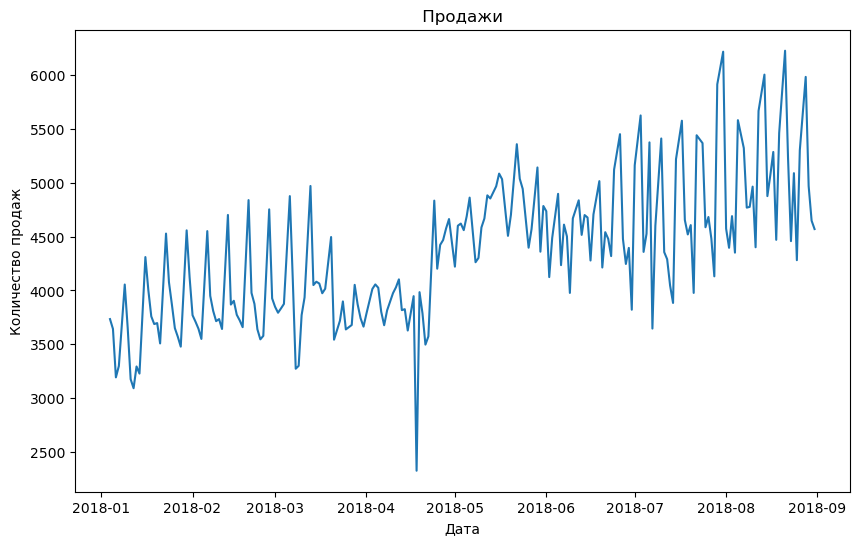

In [18]:
plt.figure(figsize = (10, 6))
plt.plot(grouped_df.index, grouped_df.values)
plt.title(' Продажи ')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Продажи сильно колеблются, но в целом идет рост среднего значения

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [ ]:
Как видно на графике, сильно резкое падение идет на середину апреля месяца

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [23]:
df['Месяц'] = df['Дата'].dt.month
df['ДеньНедели'] = df['Дата'].dt.weekday
df

,Дата,Склад,Контрагент,Номенклатура,Количество,Месяц,ДеньНедели
0,2018-01-04,1,address_0,product_0,4,1,3
1,2018-01-04,1,address_0,product_1,4,1,3
2,2018-01-04,1,address_0,product_2,5,1,3
3,2018-01-04,1,address_0,product_3,10,1,3
4,2018-01-04,1,address_0,product_4,2,1,3
...,...,...,...,...,...,...,...
301350,2018-08-31,5,address_173,product_15,0,8,4
301351,2018-08-31,5,address_173,product_17,1,8,4
301352,2018-08-31,5,address_173,product_18,1,8,4
301353,2018-08-31,5,address_173,product_19,0,8,4


In [24]:
new = (df['Месяц'].isin([6, 7, 8])) & (df['ДеньНедели'] == 2) & (df['Склад'] == 3)
filtered = df[new]
filtered

,Дата,Склад,Контрагент,Номенклатура,Количество,Месяц,ДеньНедели
191165,2018-06-06,3,address_206,product_0,2,6,2
191166,2018-06-06,3,address_206,product_1,4,6,2
191167,2018-06-06,3,address_206,product_2,4,6,2
191168,2018-06-06,3,address_206,product_3,2,6,2
191169,2018-06-06,3,address_206,product_4,1,6,2
...,...,...,...,...,...,...,...
298028,2018-08-29,3,address_112,product_2,3,8,2
298029,2018-08-29,3,address_112,product_3,3,8,2
298030,2018-08-29,3,address_112,product_4,2,8,2
298031,2018-08-29,3,address_112,product_5,1,8,2


In [22]:
result = filtered.groupby('Номенклатура')['Количество'].sum().reset_index()

top_product = result.sort_values('Количество', ascending=False).head(1)
print(top_product)

  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [38]:
print('здесь пожалуй скипну')

здесь пожалуй скипну
